# Super resolution

Super-resolution (SR) can have different meanings:
- temporal resolution
- Spectral resolution
- Spatial resolution

We consider the case of spatial resolution.

```{figure} immagini_sorgente/sr1.png
---
width: 80%
align: center
---
```

<p align="center">
  <img src="immagini_sorgente\sr1.png"  width="700">
  <p align="center"> 
</p>


Birth of SR: Blade Runner movie (1982).

- SR refers to obtaining an image at a higher resolution than that of the camera sensor.

- SR from a single image (SISR) is a highly ill-posed problem.

- The problem bemoes easier when you have a sequence of low-resolution frames of the same
      scene, acquired for example by a camera.

- In this case the algorithm reconstructs a single high resolution image from the sequence by  also removing blurring.




*Super resolution tasks*

Satellite images 

```{figure} immagini_sorgente/sr2.png
---
width: 80%
align: center
---
```

<p align="center">
  <img src="immagini_sorgente\sr2.png"  width="400">
  <p align="center"> 
</p>

```{figure} immagini_sorgente/sr3.png
---
width: 80%
align: center
---
```

Medical images (echography)

<p align="center">
  <img src="immagini_sorgente\sr3.png"  width="500">
  <p align="center"> 
</p>


Surveillance


```{figure} immagini_sorgente/sr4.png
---
width: 50%
align: center
---
```

<p align="center">
  <img src="immagini_sorgente\sr4.png"  width="200">
  <p align="center"> 
</p>



Microscopy images 

```{figure} immagini_sorgente/sr5.png
---
width: 50%
align: center
---
```

<p align="center">
  <img src="immagini_sorgente\sr5.png"  width="300">
  <p align="center"> 
</p>

*Basic SR algorithms*

The nearest neighbour (NN) super-resolution algorithm is the simplest method used to increase the resolution of an image. In reality it does not create new details: it simply replicates existing pixels.

Basic idea
When you enlarge a low-resolution image, each new pixel in the high-resolution image takes the value of the closest pixel in the original image.

```{figure} immagini_sorgente/sr7.png
---
width: 60%
align: center
---
```
<p align="center">
  <img src="immagini_sorgente\sr7.png"  width="400">
  <p align="center"> 
</p>

```{figure} immagini_sorgente/sr8.png
---
width: 60%
align: center
---
```

<p align="center">
  <img src="immagini_sorgente\sr8.png"  width="400">
  <p align="center"> 
</p>

*Mathematical formulation.*

Suppose $I_LR(i,j)$ the low resolution image.
To obtain the high resolution image $I_{HR}$, given a scaling factor $s$:

$$I_{HR}(i,j)=I_{LR}(round(\frac{i}{s},round\frac{j}{s}))$$

That means we take the pixel of the original image that is closest to the corresponding position.

Example:

Original image:

$$\begin{pmatrix}
1 & 2 \\
3& 4 \\
\end{pmatrix}$$

High resolution after nearest neighbour:

$$
\begin{bmatrix}
1 & 1 & 2 & 2 \\
1 & 1 & 2 & 2 \\
3 & 3 & 4 & 4 \\
3 & 3 & 4 & 4
\end{bmatrix}
$$

Advantages

✔ very fast

✔ very simple

✔ does not introduce new pixel values

Disadvantages

✘ produces blocky / pixelated images

✘ does not reconstruct details

✘ lower quality compared to other interpolation methods

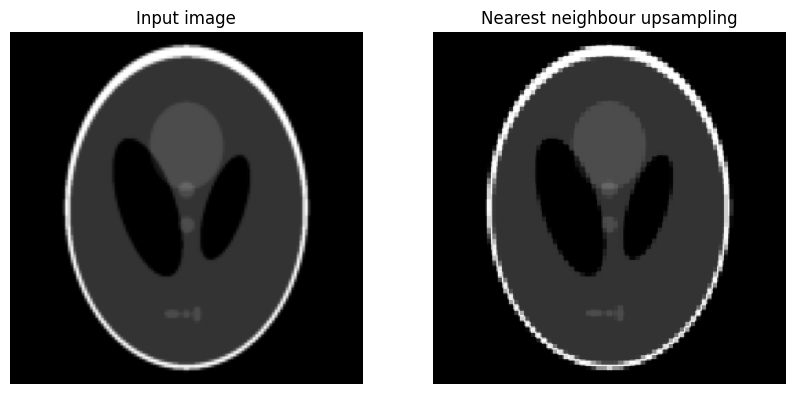

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.data import shepp_logan_phantom
from skimage.transform import resize


def nearest_neighbor_resize(img, scale):

    h, w = img.shape
    new_h = int(h * scale)
    new_w = int(w * scale)

    out = np.zeros((new_h, new_w))

    for i in range(new_h):
        for j in range(new_w):

            x = round(i / scale)
            y = round(j / scale)

            x = min(x, h-1)
            y = min(y, w-1)

            out[i, j] = img[x, y]

    return out


# immagine di input
size=128
phantom = shepp_logan_phantom()
img = resize(phantom, (size, size), anti_aliasing=True, preserve_range=True)

#img = data.camera()

# fattore di scala
scale = 2

# applicazione algoritmo
img_up = nearest_neighbor_resize(img, scale)

# visualizzazione
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Input image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_up, cmap='gray')
plt.title("Nearest neighbour upsampling")
plt.axis("off")

plt.show()

Another possible approach is to interpolate the values of adjacent pixels 
(bilinear or bicubic  interpolation upscaling)

```{figure} immagini_sorgente/sr9.png
---
width: 60%
align: center
---
```

<p align="center">
  <img src="immagini_sorgente\sr9.png"  width="400">
  <p align="center"> 
</p>

In interpolation-based super-resolution, the resolution of an image is increased by estimating the values of new pixels using nearby pixels from the original image. Two common classical methods are bilinear interpolation and bicubic interpolation.

*Bilinear interpolation*

Idea:

The value of each new pixel is computed as a weighted average of the 4 nearest pixels.

The interpolation is linear in two directions:

- first along the x direction
- then along the y direction

Assume that the new points lie between these four pixels:

$$\begin{pmatrix}
I_{11}& I_{12} \\
I_{21}& I_{22} \\
\end{pmatrix}$$

Each of the four pixels contributes with a weight proportional to its distance from the new point.
Pixels closer to the new position have larger weights.

Results:
- smoother image than nearest neighbour
- reduced block artifacts
- still slightly blurred

*Bicubic interpolation*

Bicubic interpolation uses 16 surrounding pixels (a 4×4 neighborhood) instead of 4.
The interpolation is based on cubic polynomials, which provide smoother and more accurate estimates.

Results:

-  smoother images
-  sharper edges
- less blur compared to bilinear interpolation

Comparison:

```{figure} immagini_sorgente/sr12.png
---
width: 100%
align: center
---
```
<p align="center">
  <img src="immagini_sorgente\sr12.png"  width="700">
  <p align="center"> 
</p>

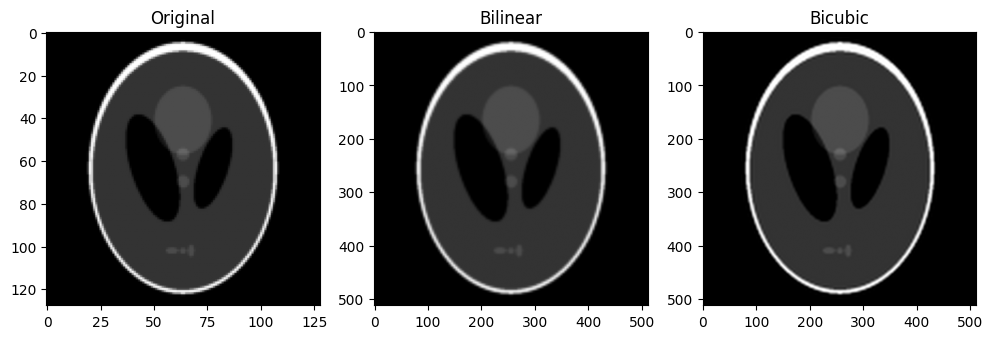

In [10]:
bilinear = resize(img, (512,512), order=1)
bicubic = resize(img, (512,512), order=3)

plt.figure(figsize=(12,4))

plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title("Original")

plt.subplot(132)
plt.imshow(bilinear, cmap='gray')
plt.title("Bilinear")

plt.subplot(133)
plt.imshow(bicubic, cmap='gray')
plt.title("Bicubic")

plt.show()

*Super resolution as an inverse problem*

```{figure} immagini_sorgente/sr6.png
---
width: 90%
align: center
---
```

<p align="center">
  <img src="immagini_sorgente\sr6.png"  width="700">
  <p align="center"> 
</p>

$y_k$: low resolution acquired image

$x$: original high resolution image

$B_k$: blur model such as optical or motion blur

$D$: downsampling operator

*Downsampling operators*

Zero padding:

```{figure} immagini_sorgente/sr10.png
---
width: 100%
align: center
---
```

<p align="center">
  <img src="immagini_sorgente\sr10.png"  width="500">
  <p align="center"> 
</p>

Average:

```{figure} immagini_sorgente/sr11.png
---
width: 90%
align: center
---
```
<p align="center">
  <img src="immagini_sorgente\sr11.png"  width="400">
  <p align="center"> 
</p>
